<a href="https://colab.research.google.com/github/sauraviitj/neural-networks-zero-to-hero/blob/main/micrograd_lecture_first_half.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##MICROGRAD
A tiny Autograd engine (with a bite! :)). Implements backpropagation (reverse-mode autodiff) over a dynamically built DAG and a small neural networks library on top of it with a PyTorch-like API. Both are tiny, with about 100 and 50 lines of code respectively. The DAG only operates over scalar values, so e.g. we chop up each neuron into all of its individual tiny adds and multiplies. However, this is enough to build up entire deep neural nets doing binary classification, as the demo notebook shows. Potentially useful for educational purposes.

In [ ]:
#Cell 1
pip install micrograd

##Example usage

Below is a slightly contrived example showing a number of possible supported operations:

In [ ]:
#Cell 2
from micrograd.engine import Value  # Import the Value class that stores a scalar value, gradient, and computation history

a = Value(-4.0)                    # Create input node a with value -4.0
print(a)                           # Display Value object showing data and current gradient
print(a.data)                      # Print the numerical value stored in a
print(a.grad)                      # Print gradient of a (initially 0)

b = Value(2.0)                     # Create input node b with value 2.0

c = a + b                          # Add a and b, create graph node c = -2
d = a * b + b**3                   # Compute d = (a×b) + b³, create graph nodes for multiplication, power and addition

c += c + 1                         # Update c by adding itself and 1, expands the computation graph
c += 1 + c + (-a)                  # Update c again using current c, constant 1 and negative of a

d += d * 2 + (b + a).relu()        # Update d using d×2 and ReLU activation of (b+a), RELU means if x>0 then output x or else 0 here b+a=-2 i.e. op will be 0
d += 3 * d + (b - a).relu()        # Update d using 3×d and ReLU activation of (b-a)

e = c - d                          # Compute difference between c and d
f = e**2                           # Square e to obtain a non-negative value
g = f / 2.0                        # Divide f by 2
g += 10.0 / f                      # Add reciprocal-based term 10/f to g

print(f'{g.data:.4f}')             # Print final forward-pass result rounded to 4 decimals

g.backward()                       # Run backpropagation to compute gradients of all nodes

print(f'{a.grad:.4f}')             # Print gradient dg/da, sensitivity of output g to input a
print(f'{b.grad:.4f}')             # Print gradient dg/db, sensitivity of output g to input b

Value(data=-4.0, grad=0)
-4.0
0
24.7041
138.8338
645.5773


```text
      → c →
a →          → e → f → g
      → d →
```

```text
Chain Rule:

dg/da = dg/df × df/de * ( de/dc × dc/da + de/dd × dd/da)



## Now Back to basics

In [16]:
#Cell 3
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
#Cell 4
def f(x):
  return 3*x**2 - 4*x + 5

In [18]:
#Cell 5
f(3.0)

20.0

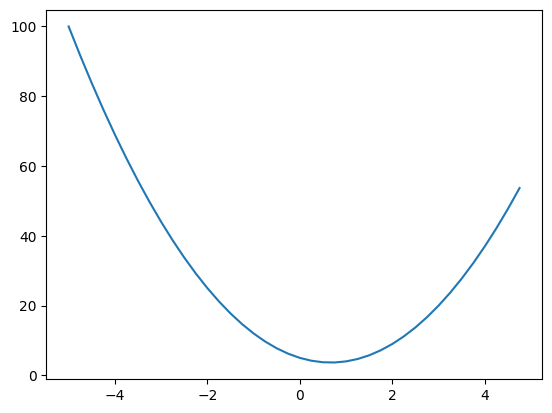

In [19]:
#Cell 6
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

Calculating derivative using traditional derivative formula:

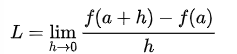

In [20]:
#Cell 7
h = 0.0000001
x = 2/3
(f(x + h) - f(x))/h #derivative at point X =2/3

2.9753977059954195e-07

In [21]:
#Cell 8
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [22]:
#Cell 9
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h) #sderivative for a*b+c


d1 4.0
d2 4.0001
slope 0.9999999999976694


#graphviz is used for visualisation

In [23]:
#Cell 10
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    #dot.node(name = uid, label = "{ data %.4f }" % (n.data), shape='record')
    dot.node(name = uid, label = "{ %s | data %.4f |grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


#class, function, __init__, self, -children

```text
class Value:              # Class (blueprint)

    def __init__(...):    # Constructor

    def __repr__(...):    # Print representation

    def __add__(...):     # Defines +

    def __mul__(...):     # Defines *

a = Value(2.0)            # Object/instance

b = Value(-3.0)           # Object/instance

c = Value(10.0)           # Object/instance

d = a*b + c               # Creates new object d

d._prev                   # Parent nodes used to create d
```


```text

class        = Blueprint

object       = Instance created from blueprint

__init__     = Constructor (runs automatically during object creation)

self         = Current object ("this object")

method       = Function inside a class

      __add__      = Defines +

      __mul__      = Defines *

      __repr__     = Defines print()

other        = The second operand (e.g. b in a+b)

_children    = Nodes used to create current node

_prev        = Stores parent nodes for backpropagation

```



In [24]:
#Cell 11
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data= data
    self.grad= 0.0
    self._prev= set(_children)
    self._op= _op
    self.label=label

  def __repr__(self):
    return f"Value(data={self.data})"
  def __add__(self, other):
    out= Value(self.data + other.data, (self,other), '+')
    return out
  def __mul__(self, other):
    out= Value(self.data * other.data, (self,other), '*')
    return out
a=Value(2.0, label='a')
b=Value(-3.0, label='b')
c=Value(10.0, label='c')

e=a*b;  e.label='e'
#just a+b will not work as python doesnt not know how to add the objects a and b, thus we define the function _add__
#d=a*b+c ((a.__mul__b).__add__(c) )
d=e+c; d.label='d'  #((a.__mul__b).__add__(c) )
print(d)
print(d._prev) # d contains c and (a+B) thus it outputs -6 and 10
print(d._op)
print(e._op) #This version of Value does two things:Stores the numerical result of an operation.Remembers which operation (+) created the result using _op.
f=Value(-2.0, label='f')
L=d*f; L.label='L' #its like loss function
print(L)



Value(data=4.0)
{Value(data=10.0), Value(data=-6.0)}
+
*
Value(data=-8.0)


#workflow when one enters a= Value(2)
```text
a = Value(2.0)
        │
        ▼
__init__ runs
        │
        ▼
a.data = 2.0
        │
        ▼
print(a)
        │
        ▼
Python looks for __repr__()
        │
        ▼
a.__repr__()
        │
        ▼
returns "Value(data=2.0)"
        │
        ▼
print("Value(data=2.0)")
        │
        ▼
Value(data=2.0)


```

_children = nodes used to create the current node

_prev = stores those nodes for backpropagation

Example:
c = a + b

c._prev = {a,b}

This information lets micrograd traverse the computation graph backwards during backward().

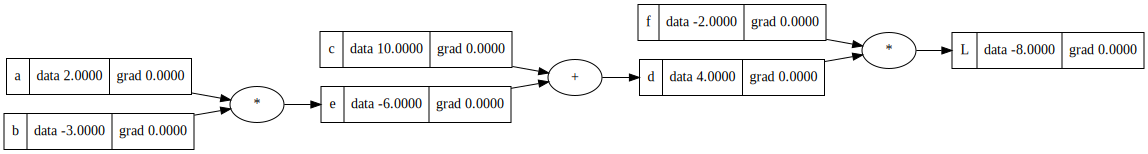

In [25]:
#Cell 12
draw_dot(L)

### Gradient Estimation

To estimate:

$$
\frac{dL}{da}
$$

use:

$$
\frac{L(a+h)-L(a)}{h}
$$

Steps:

1. Compute `L(a)`
2. Increase `a` by a tiny amount `h`
3. Compute `L(a+h)`
4. Divide the change in output by `h`

Rule:

- Multiply along a path
- Add across multiple paths
- Gradient = slope of output with respect to input

In [26]:
#Cell 14
def lol():  # dl/dla
  h=0.0001

  a=Value(2.0, label='a')
  b=Value(-3.0, label='b')
  c=Value(10.0, label='c')
  e=a*b;  e.label='e'
  d=e+c; d.label='d'
  f=Value(-2.0, label='f')
  L=d*f; L.label='L'
  L1=L.data


 # a=Value(2.0 +h, label='a') # for dl/da
  a=Value(2.0, label='a')
  b=Value(-3.0, label='b')
  c=Value(10.0, label='c')
  e=a*b;  e.label='e'
  d=e+c; d.label='d'
  f=Value(-2.0, label='f')
  L=d*f; L.label='L'
  L2=L.data+h #for dl/dl

  print((L2-L1)/h)


lol()


0.9999999999976694



$$
\frac{dl}{dd}
$$
, use
$$
\frac{(d+h)*f -d*f}{h}
$$
, so if we test it in the above cell we will get the same value as the manual value we set below i.e. d.grad

In [27]:
#Cell 15 Back propagation example 1
L.grad=1.0 #this is dl/dl setting it manually for backpropagation , 0.99999 is approx 1 in cell 14 is used for checking the manual values
d.grad=-2 #manually set gradient for backpropagation but it will be same value
f.grad= 4
c.grad=-2
e.grad=-2
b.grad= -2.0 * 2.0
a.grad= -2.0 * -3.0

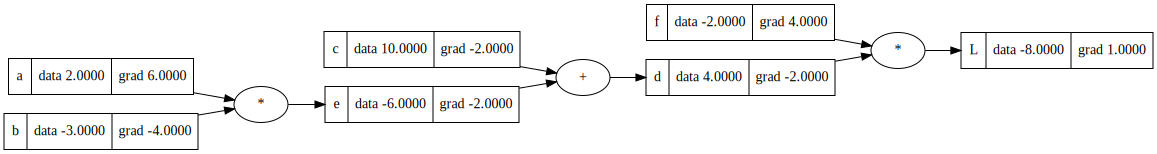

In [28]:
#Cell 16
draw_dot(L)

### Computing c.grad

We are interested in finding:

$$
\frac{dL}{dc}
$$

which means:

> How much does the output \(L\) change if \(c\) is changed slightly?

The path from \(c\) to \(L\) is:

```text
c → d → L
```

Using the Chain Rule:

$$
\frac{dL}{dc}
=
\frac{dL}{dd}
\times
\frac{dd}{dc}
$$

Since:

$$
d = c + e
$$

we have:

$$
\frac{dd}{dc}=1
$$

and from the previous step:

$$
d.grad = \frac{dL}{dd} = -2
$$

Therefore:

$$
c.grad
=
d.grad \times 1
=
-2
$$

---

### Computing a.grad

We are interested in finding:

$$
\frac{dL}{da}
$$

Path:

```text
a → e → d → L
```

Using the Chain Rule:

$$
\frac{dL}{da}
=
\frac{dL}{dd}
\times
\frac{dd}{de}
\times
\frac{de}{da}
$$

Since:

$$
e = a \times b
$$

we have:

$$
\frac{de}{da}=b=-3
$$

and from the previous step:

$$
e.grad = \frac{dL}{de} = -2
$$

Therefore:

$$
a.grad
=
e.grad \times \frac{de}{da}
=
(-2)\times(-3)
=
6
$$

In [29]:
#Cell 17

# changing the leaf node by some amount  parameter -= learning_rate * gradient
a.data -= 0.01 * a.grad
# Increase a by a small amount proportional to its gradient
b.data -= 0.01 * b.grad
# Increase b by a small amount proportional to its gradient
c.data -= 0.01 * c.grad
# Increase c by a small amount proportional to its gradient
f.data -= 0.01 * f.grad
# Increase f by a small amount proportional to its gradient
e = a * b
# Recalculate e using updated values
d = e + c
# Recalculate d using updated values
L = d * f
# Recalculate final output L
print(L.data)

-8.726303999999999


lambda is a small, anonymous function that is defined without a name.
e.g.
```
square_lambda = lambda x: x * x

print(square_lambda(5))  # Output: 25
```
is same as
```
def square(x):
    return x * x

print(square(5))  # Output: 25

```

In [30]:
#Cell 18
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None # It creates a tiny function that does nothing by default but functions like  out._backward = _backward make it work
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      # Backpropagation rule for addition (out = self + other)

      # d(out)/d(self) = 1
      # Therefore:
      # dL/d(self) = dL/d(out) * d(out)/d(self)
      #            = out.grad * 1
      self.grad += 1.0 * out.grad

      # d(out)/d(other) = 1
      # Therefore:
      # dL/d(other) = dL/d(out) * d(out)/d(other)
      #             = out.grad * 1
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():

    # d(out)/d(self) = other
    # dL/d(self) = dL/d(out) * d(out)/d(self)
    #            = out.grad * other
      self.grad += other.data * out.grad

      # d(out)/d(other) = self
      # dL/d(other) = dL/d(out) * d(out)/d(other)
      #             = out.grad * self
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh') # Create output node from tanh(self), store self as the only parent because tanh takes a single input

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

## Important Notes About Backpropagation

### What does `.grad` store?

For any node `x`:

$$
x.grad = \frac{dL}{dx}
$$

where `L` is the final output node.

Examples:

$$
a.grad = \frac{dL}{da}
$$

$$
e.grad = \frac{dL}{de}
$$

$$
L.grad = \frac{dL}{dL}=1
$$

---

### What is `out.grad`?

For:

```python
out = self * other
```

`out.grad` already contains:

$$
\frac{dL}{d(out)}
$$

i.e. the gradient arriving from the nodes after `out`.

Think:

```text
future nodes
     │
     ▼
   out.grad
     │
     ▼
 current node
```

---

### Why do we multiply by `out.grad`?

Chain Rule:

$$
\frac{dL}{d(self)}
=
\frac{dL}{d(out)}
\times
\frac{d(out)}{d(self)}
$$

Micrograd:

```python
self.grad += out.grad * local_derivative
```

Examples:

For:

```python
out = self + other
```

$$
\frac{d(out)}{d(self)}=1
$$

```python
self.grad += 1 * out.grad
```

For:

```python
out = self * other
```

$$
\frac{d(out)}{d(self)}=other
$$

```python
self.grad += other.data * out.grad
```

---

### Why use += instead of = ?

Because a node may receive gradient from multiple paths.

Example:

```text
      b ----\
     /       \
a ---         ---> o
     \       /
      c ----/
```

Then:

$$
\frac{do}{da}
=
\frac{do}{db}\frac{db}{da}
+
\frac{do}{dc}\frac{dc}{da}
$$

Notice the PLUS sign.

Gradients from multiple paths must be ADDED.

Therefore:

```python
a.grad += contribution_from_path1
a.grad += contribution_from_path2
```

Final:

```python
a.grad =
path1 + path2
```

If we used:

```python
a.grad = contribution
```

the previous contribution would be lost.

---

### Initially, all gradients are zero

When a Value is created:

```python
self.grad = 0.0
```

So the first update:

```python
a.grad += contribution
```

is effectively:

```python
a.grad = contribution
```

The += is there to support multiple gradient contributions later.

---

### Are gradients reset automatically?

No.

Calling:

```python
L.backward()
```

does NOT reset:

```python
a.grad
b.grad
c.grad
```

They keep accumulating.

Only:

```python
L.grad = 1
```

is set automatically.

To start a fresh backward pass:

```python
a.grad = 0
b.grad = 0
c.grad = 0
...
```

must be done manually.

---

### Golden Rule

Every backward function follows:

```python
parent.grad += out.grad * local_derivative
```

Read it as:

```text
Parent gradient
=
existing gradient
+
(new contribution from this path)
```

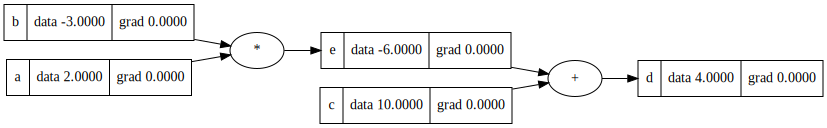

In [31]:
#Cell 19
draw_dot(d)

In [32]:
#Cell 20
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)


-8.0


In [33]:
#Cell 21
def lol():

  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1)/h)

lol()

-3.9999999999995595


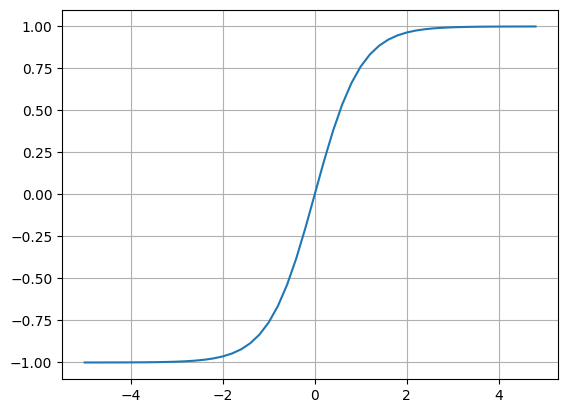

In [34]:
#Cell 22
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

```text

x1 ----\
        * ---> x1w1 ----\
w1 ----/                \
                          + ---> x1w1x2w2 ----\
x2 ----\                /                     \
        * ---> x2w2 ---/                       + ---> n ---> tanh ---> o
w2 ----/                                      /
                                              /
b -------------------------------------------/

```

In [35]:
#Cell 23 Backpropagation example 2
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'output'

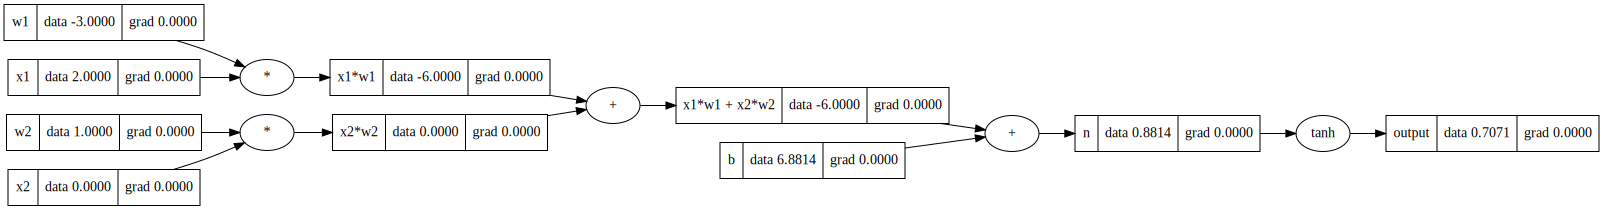

In [36]:
draw_dot(o)

In [37]:
#Cell 24
o.backward()

In [38]:
#Cell 25
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

### Backpropagation Formulas

$$
o = \tanh(n)
$$

$$
\frac{do}{do}=1
$$

$$
o.grad = 1
$$

---

$$
\frac{do}{dn}
=
1-\tanh^2(n)
=
1-o^2
$$

$$
n.grad
=
o.grad \times \frac{do}{dn}
=
1 \times (1-o^2)
=
0.5
$$

---

Since:

$$
n=(x1w1+x2w2)+b
$$

$$
\frac{dn}{d(x1w1+x2w2)}=1
$$

$$
(x1w1+x2w2).grad
=
n.grad \times 1
=
0.5
$$

---

$$
\frac{dn}{db}=1
$$

$$
b.grad
=
n.grad \times 1
=
0.5
$$

---

Since:

$$
x1w1+x2w2=x1w1+x2w2
$$

$$
\frac{d(x1w1+x2w2)}{dx1w1}=1
$$

$$
x1w1.grad
=
(x1w1+x2w2).grad \times 1
=
0.5
$$

---

$$
\frac{d(x1w1+x2w2)}{dx2w2}=1
$$

$$
x2w2.grad
=
(x1w1+x2w2).grad \times 1
=
0.5
$$

---

Since:

$$
x1w1=x1 \times w1
$$

$$
\frac{d(x1w1)}{dw1}=x1
$$

$$
w1.grad
=
x1w1.grad \times x1
=
0.5 \times 2
=
1
$$

---

$$
\frac{d(x1w1)}{dx1}=w1
$$

$$
x1.grad
=
x1w1.grad \times w1
=
0.5 \times (-3)
=
-1.5
$$

---

Since:

$$
x2w2=x2 \times w2
$$

$$
\frac{d(x2w2)}{dw2}=x2
$$

$$
w2.grad
=
x2w2.grad \times x2
=
0.5 \times 0
=
0
$$

---

$$
\frac{d(x2w2)}{dx2}=w2
$$

$$
x2.grad
=
x2w2.grad \times w2
=
0.5 \times 1
=
0.5
$$

In [39]:
o.grad = 1.0

In [40]:
o._backward()

In [41]:
n._backward()

In [42]:
b._backward()

In [43]:
x1w1x2w2._backward()

In [44]:
x2w2._backward()
x1w1._backward()

In [45]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [46]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [47]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [48]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [49]:
n.grad = 0.5

In [50]:
o.grad = 1.0

In [51]:
1 - o.data**2

0.4999999999999999

In [52]:
# o = tanh(n)
# do/dn = 1 - o**2

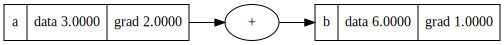

In [53]:
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)

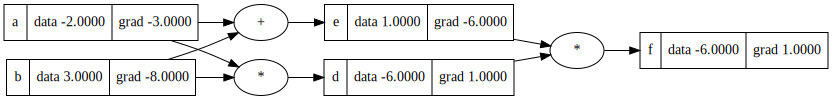

In [54]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)